# SSID 9-class detector - Run B - augmentation ON

Ultralytics' default augmentation pipeline (mosaic, HSV, scale, translate, horizontal flip). Everything else is identical to Run A, including the seed.

Model: YOLO11n | 50 epochs | imgsz 640 | batch 8 | seed fixed | RTX 3050 Laptop 4 GB

Dataset: 2,190 images (train 1,575 / val 400 / test 215), 22,957 boxes, 9 classes.
Every label row is a plain bounding box: the Roboflow export mixed bbox and polygon rows,
which Ultralytics mis-reads per file, so it was normalised with `polygons_to_bboxes.py`
first. Training a fresh export without that step corrupts thousands of boxes silently.

**No class rebalancing was applied.** `finger` really does carry 7,157 of the 16,421
training boxes; downsampling it would have deleted whole images, taking the other classes
in those frames with them. The imbalance is a property of the reported result, not a bug.


In [ ]:
from IPython.display import Image, display

## 1. Metrics

All figures are for this run only, at the default confidence threshold used by the validator.

| Metric | Validation Set | Test Set |
| --- | ---: | ---: |
| mAP@50 | 65.59% | 61.46% |
| Precision | 68.72% | 77.24% |
| Recall | 66.41% | 59.51% |
| F1 | 67.54% | 67.22% |
| mAP@50-95 | 40.07% | 36.70% |


## 2. Average precision by class (mAP@50)

| Class | Validation instances | Validation mAP@50 | Validation Precision | Validation Recall | Test instances | Test mAP@50 | Test Precision | Test Recall |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Tip_needle_holder | 291 | 87.27% | 66.41% | 91.05% | 145 | 87.06% | 82.42% | 86.90% |
| Tip_forcep | 158 | 83.74% | 71.45% | 85.44% | 81 | 80.38% | 82.99% | 75.31% |
| finger | 1775 | 78.66% | 64.31% | 83.55% | 952 | 81.24% | 74.24% | 80.04% |
| needle_holder | 525 | 76.57% | 72.88% | 76.38% | 257 | 75.76% | 75.07% | 73.54% |
| forcep | 340 | 74.87% | 81.74% | 66.76% | 176 | 75.59% | 87.74% | 64.77% |
| hand | 364 | 62.92% | 58.11% | 83.79% | 181 | 68.04% | 65.02% | 85.25% |
| wound | 467 | 58.59% | 58.54% | 58.03% | 254 | 59.47% | 69.89% | 49.35% |
| Stitch Scissors | 10 | 42.51% | 89.83% | 30.00% | 3 | 2.44% | 100.00% | 0.00% |
| needle | 366 | 25.15% | 55.22% | 22.68% | 191 | 23.17% | 57.76% | 20.42% |


**Per-class detection quality - validation set**


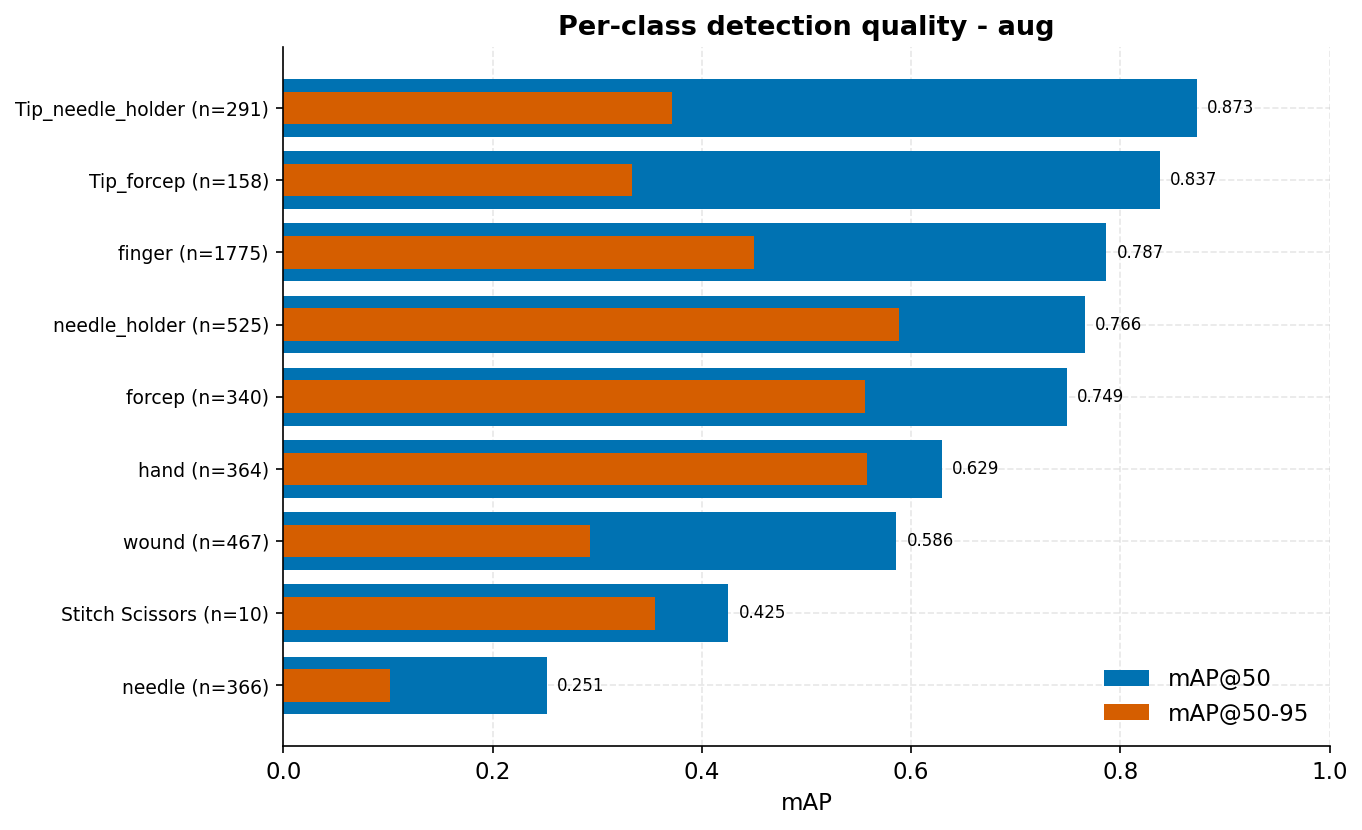

In [1]:
display(Image(filename='results/aug_per_class_map50.png'))

**Per-class detection quality - test set**


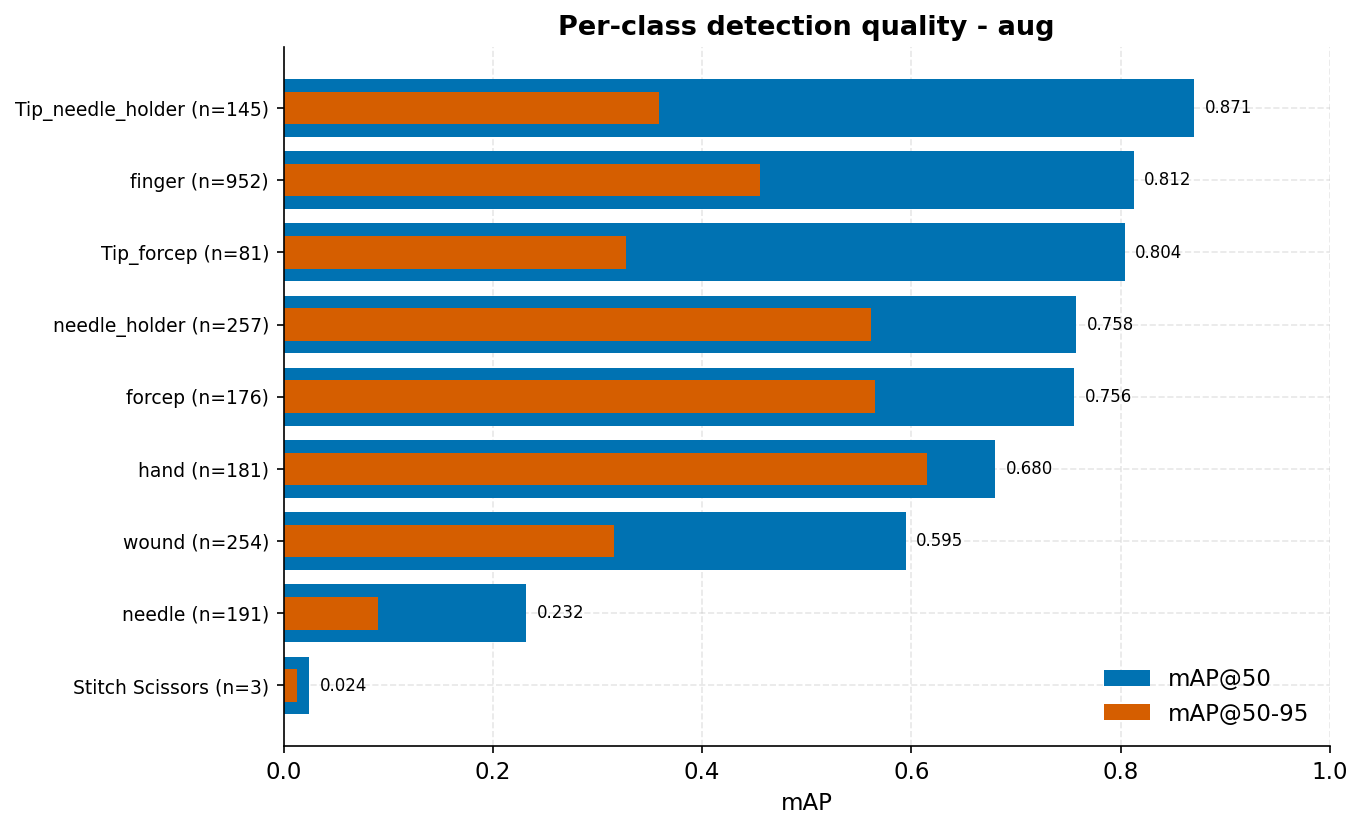

In [2]:
display(Image(filename='results_test/aug_per_class_map50.png'))

## 3. Training graphs

YOLO11 optimises **three** losses. There is no objectness loss - that belonged to YOLOv5 and
v7; distribution focal loss (DFL) is what replaced it. Each component is plotted on its own
axes because `cls_loss` starts an order of magnitude above `box_loss` and flattens the
smaller curve when they share a scale.


**Box loss (localisation)**


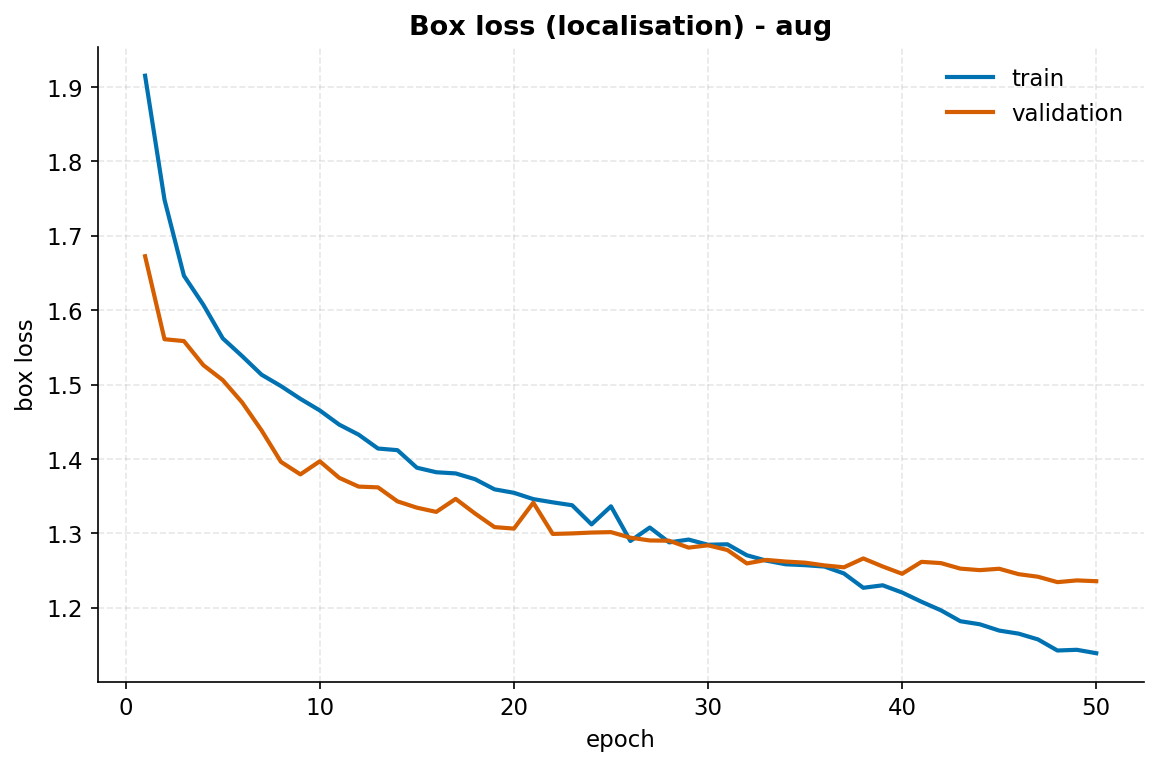

In [3]:
display(Image(filename='results/aug_box_loss.png'))

**Class loss (classification)**


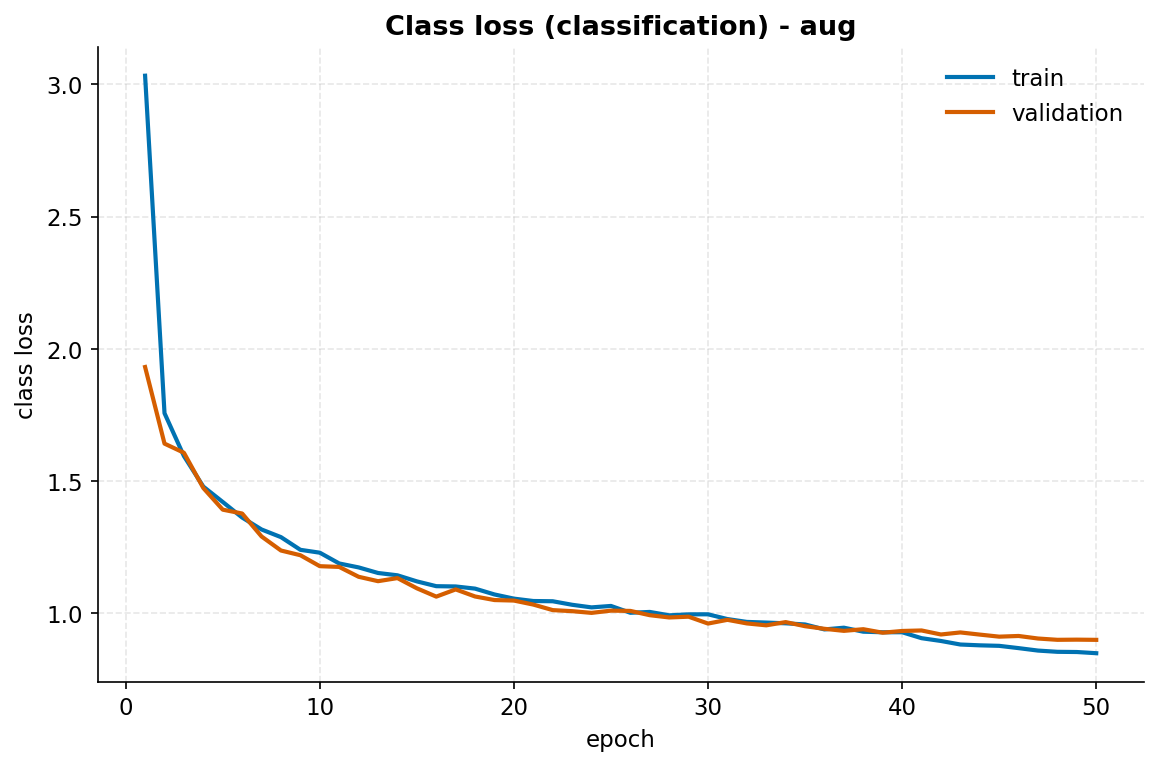

In [4]:
display(Image(filename='results/aug_cls_loss.png'))

**DFL loss (replaces objectness)**


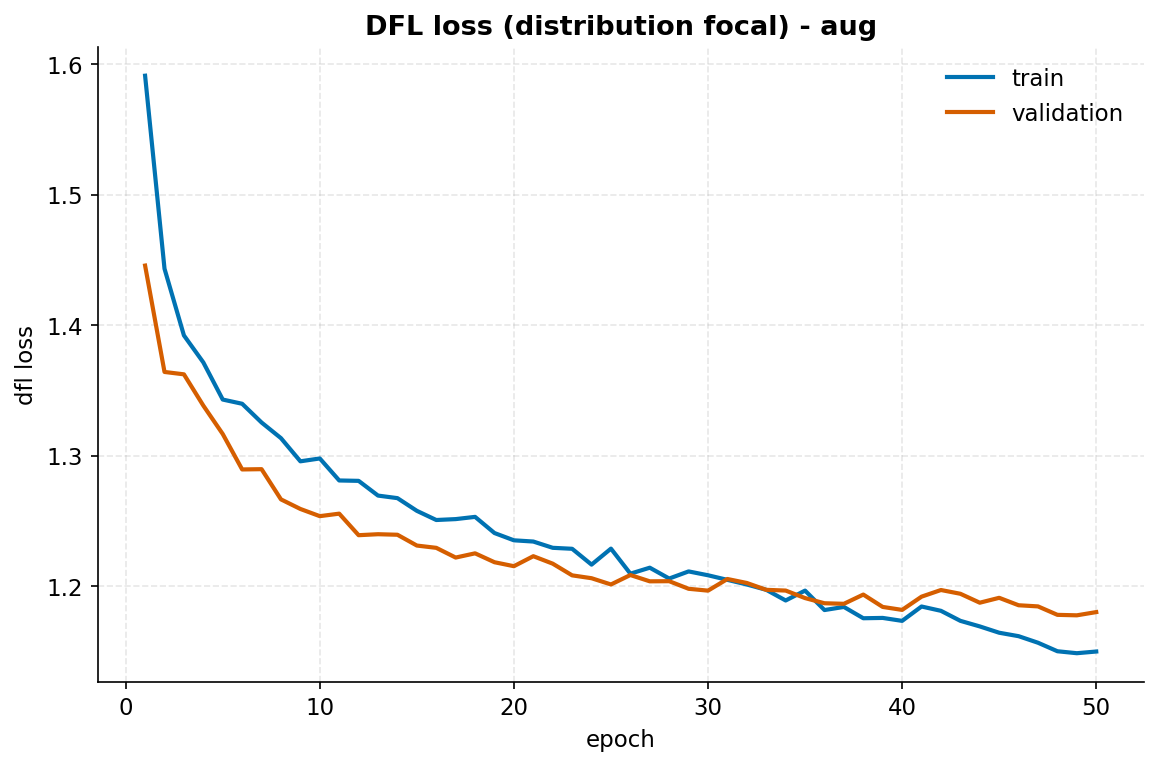

In [5]:
display(Image(filename='results/aug_dfl_loss.png'))

**Total loss, train vs validation**


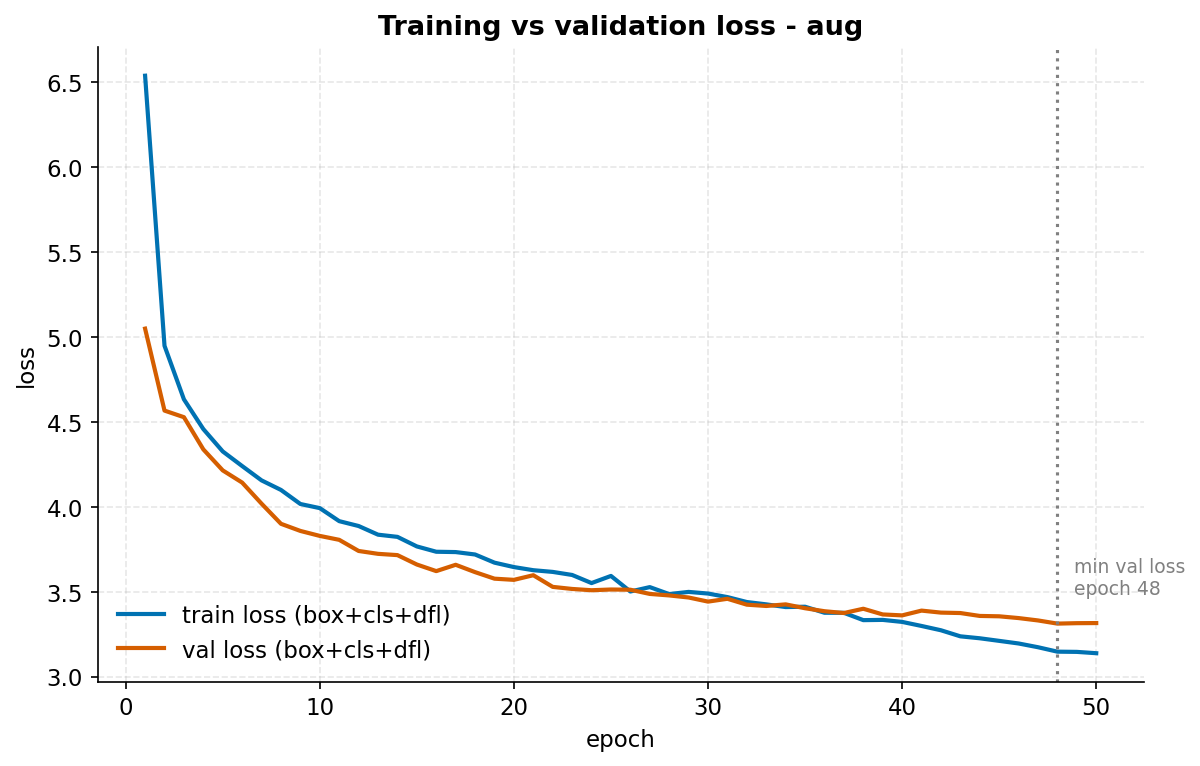

In [6]:
display(Image(filename='results/aug_loss_curve.png'))

**mAP per epoch**


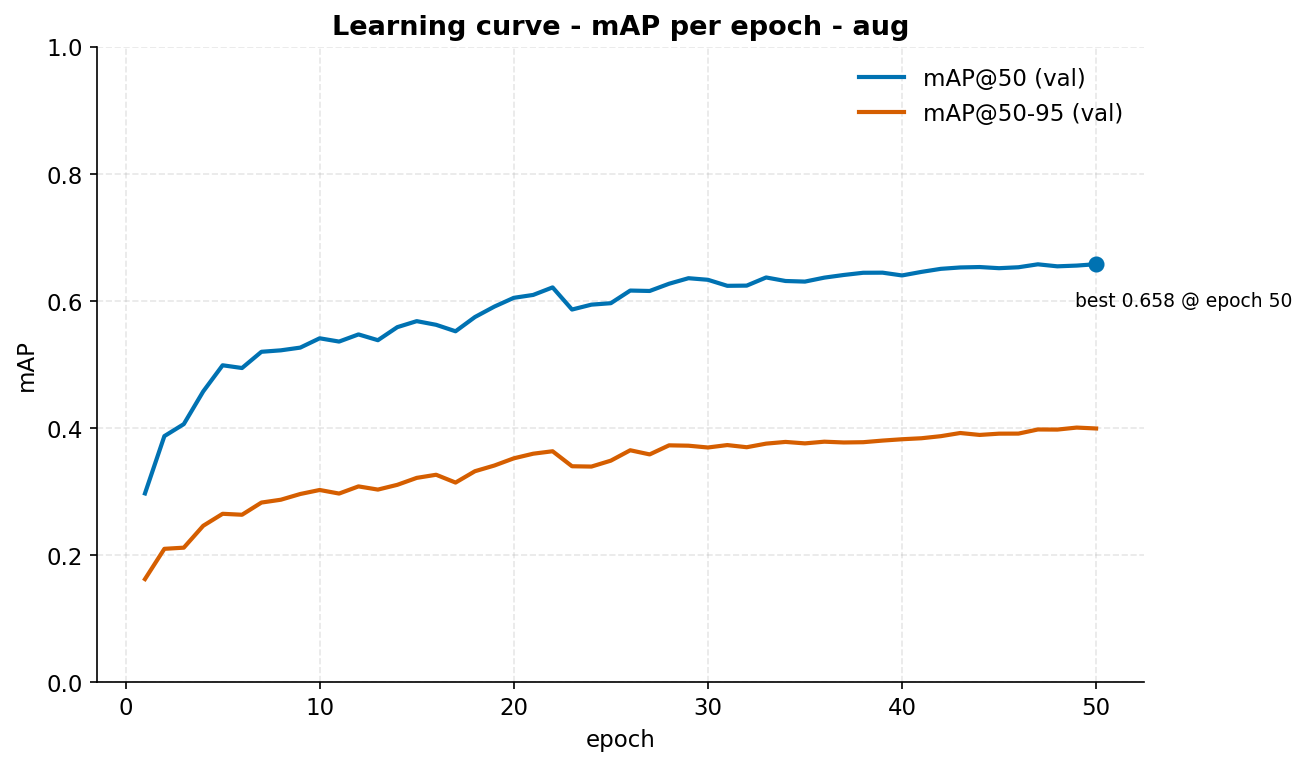

In [7]:
display(Image(filename='results/aug_learning_curve_map.png'))

**Precision and recall per epoch**


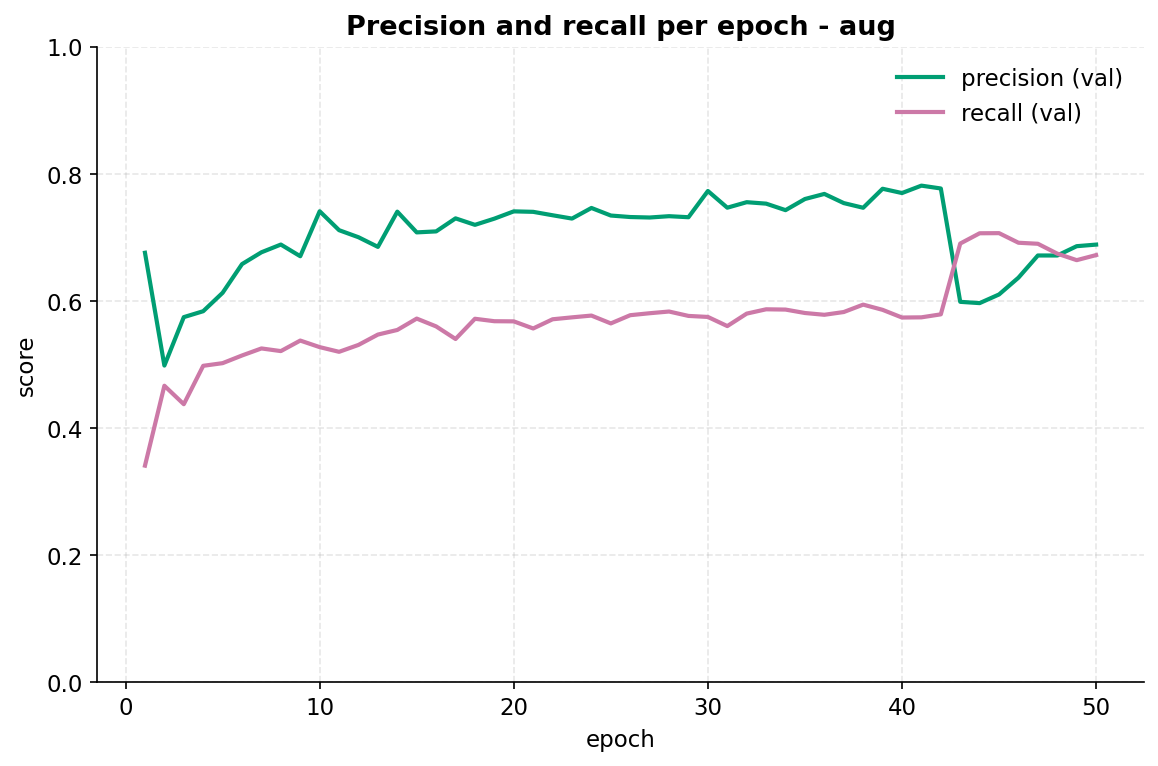

In [8]:
display(Image(filename='results/aug_precision_recall_per_epoch.png'))

**Learning rate schedule**


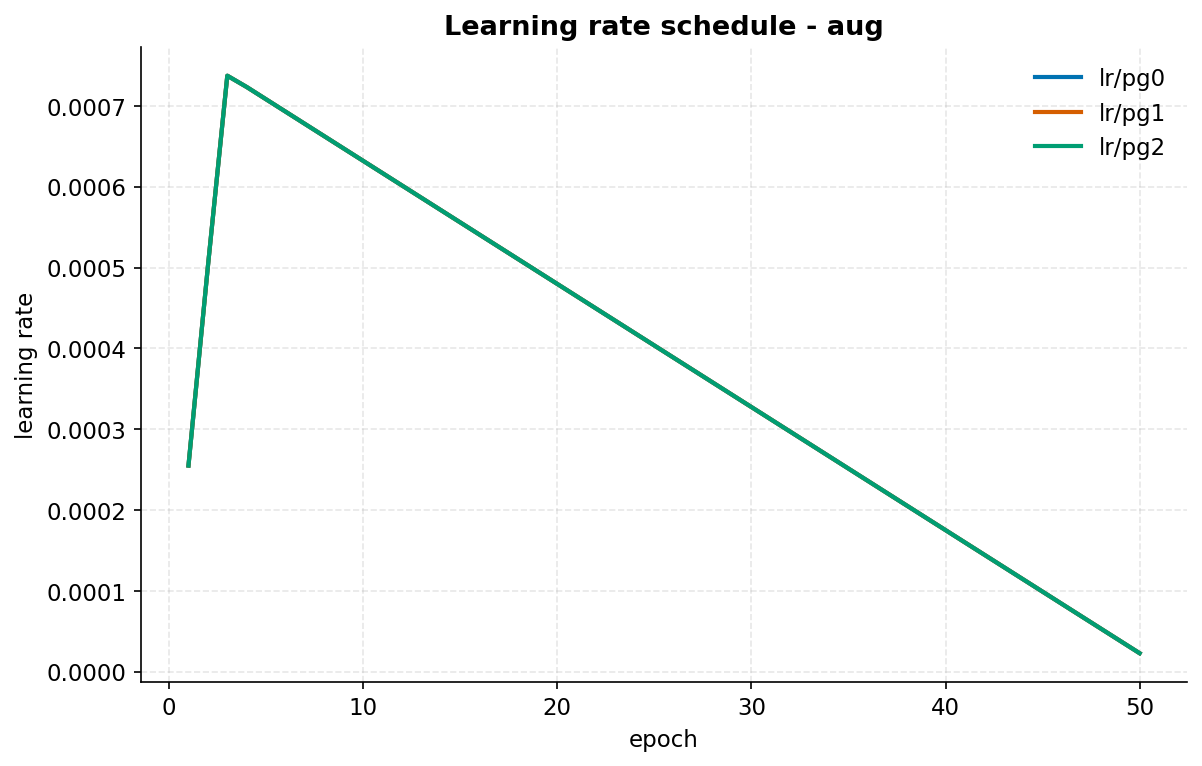

In [9]:
display(Image(filename='results/aug_lr_schedule.png'))

## 4. Confusion matrix

Columns are the true class, rows are what the model predicted, and the extra `background`
row/column is the one that matters most: the background **row** counts detections that
matched no object (false positives), and the background **column** counts real objects the
model missed entirely (false negatives). Normalisation is per true class, so each column
reads as "of all the real X in this split, what did the model call them?"


**Confusion matrix, normalised per true class - validation set**


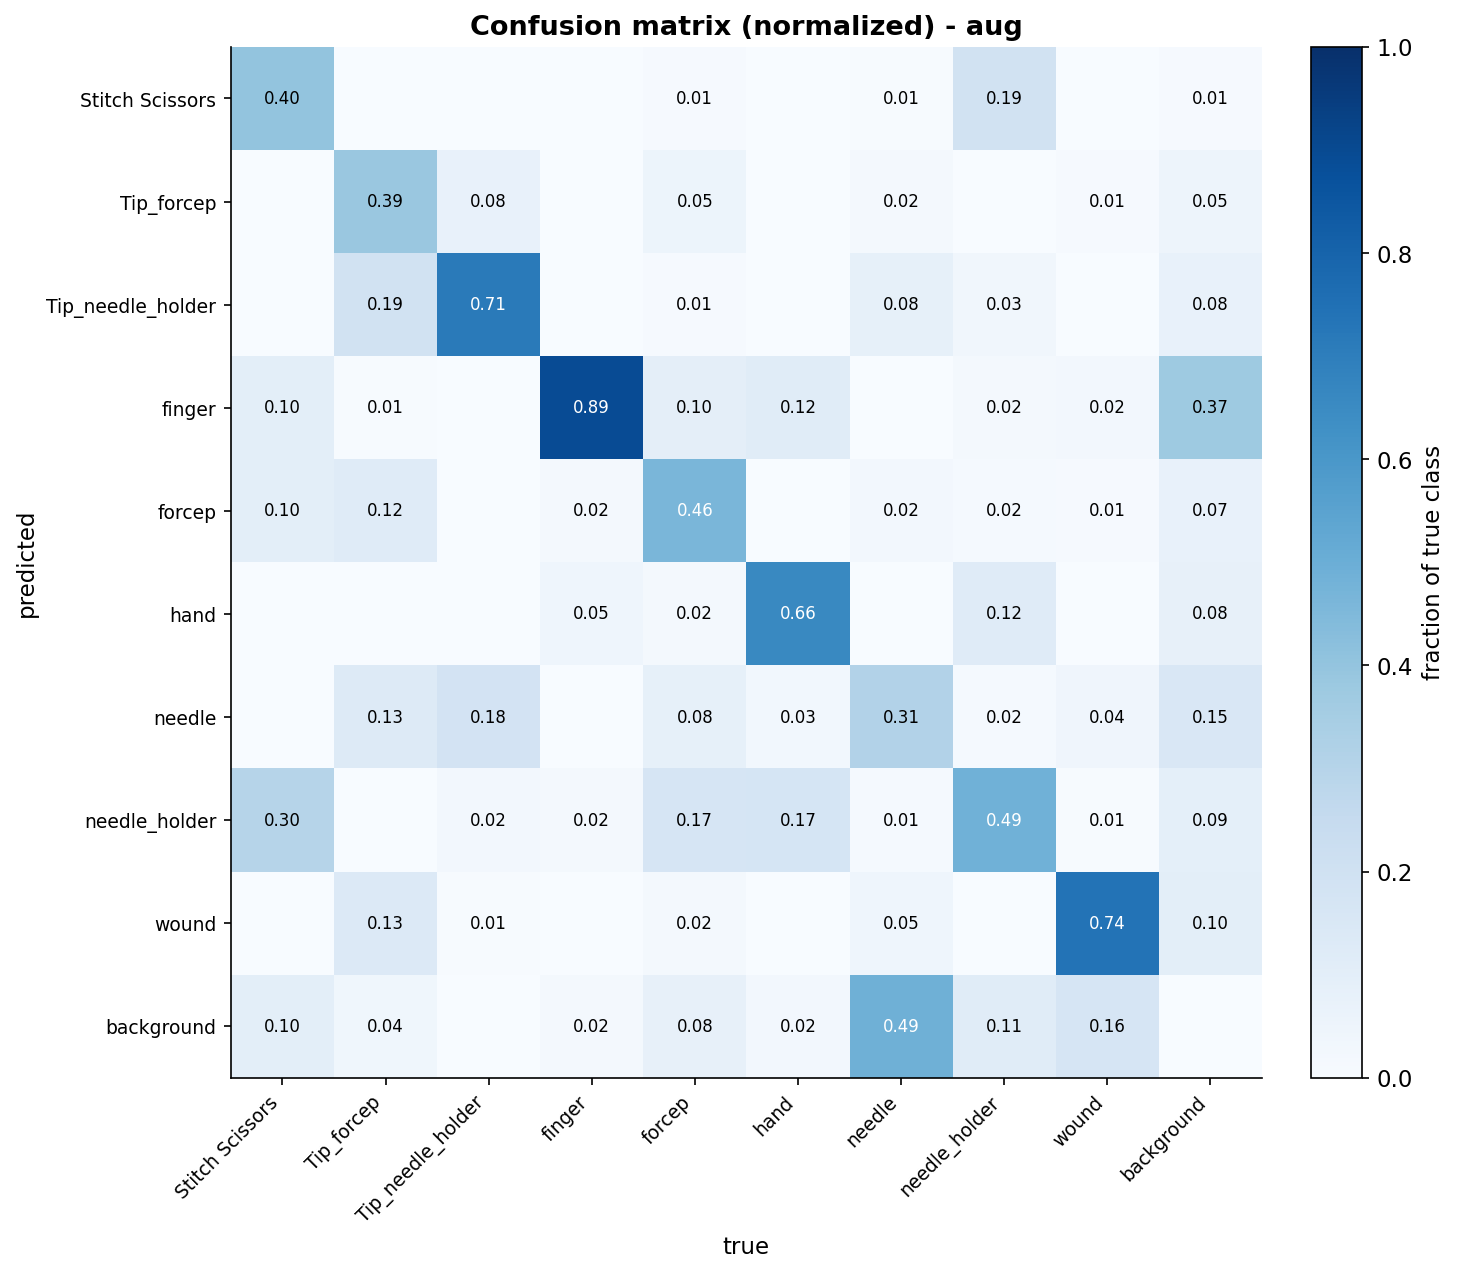

In [10]:
display(Image(filename='results/aug_confusion_matrix_normalized.png'))

**Confusion matrix, raw counts - validation set**


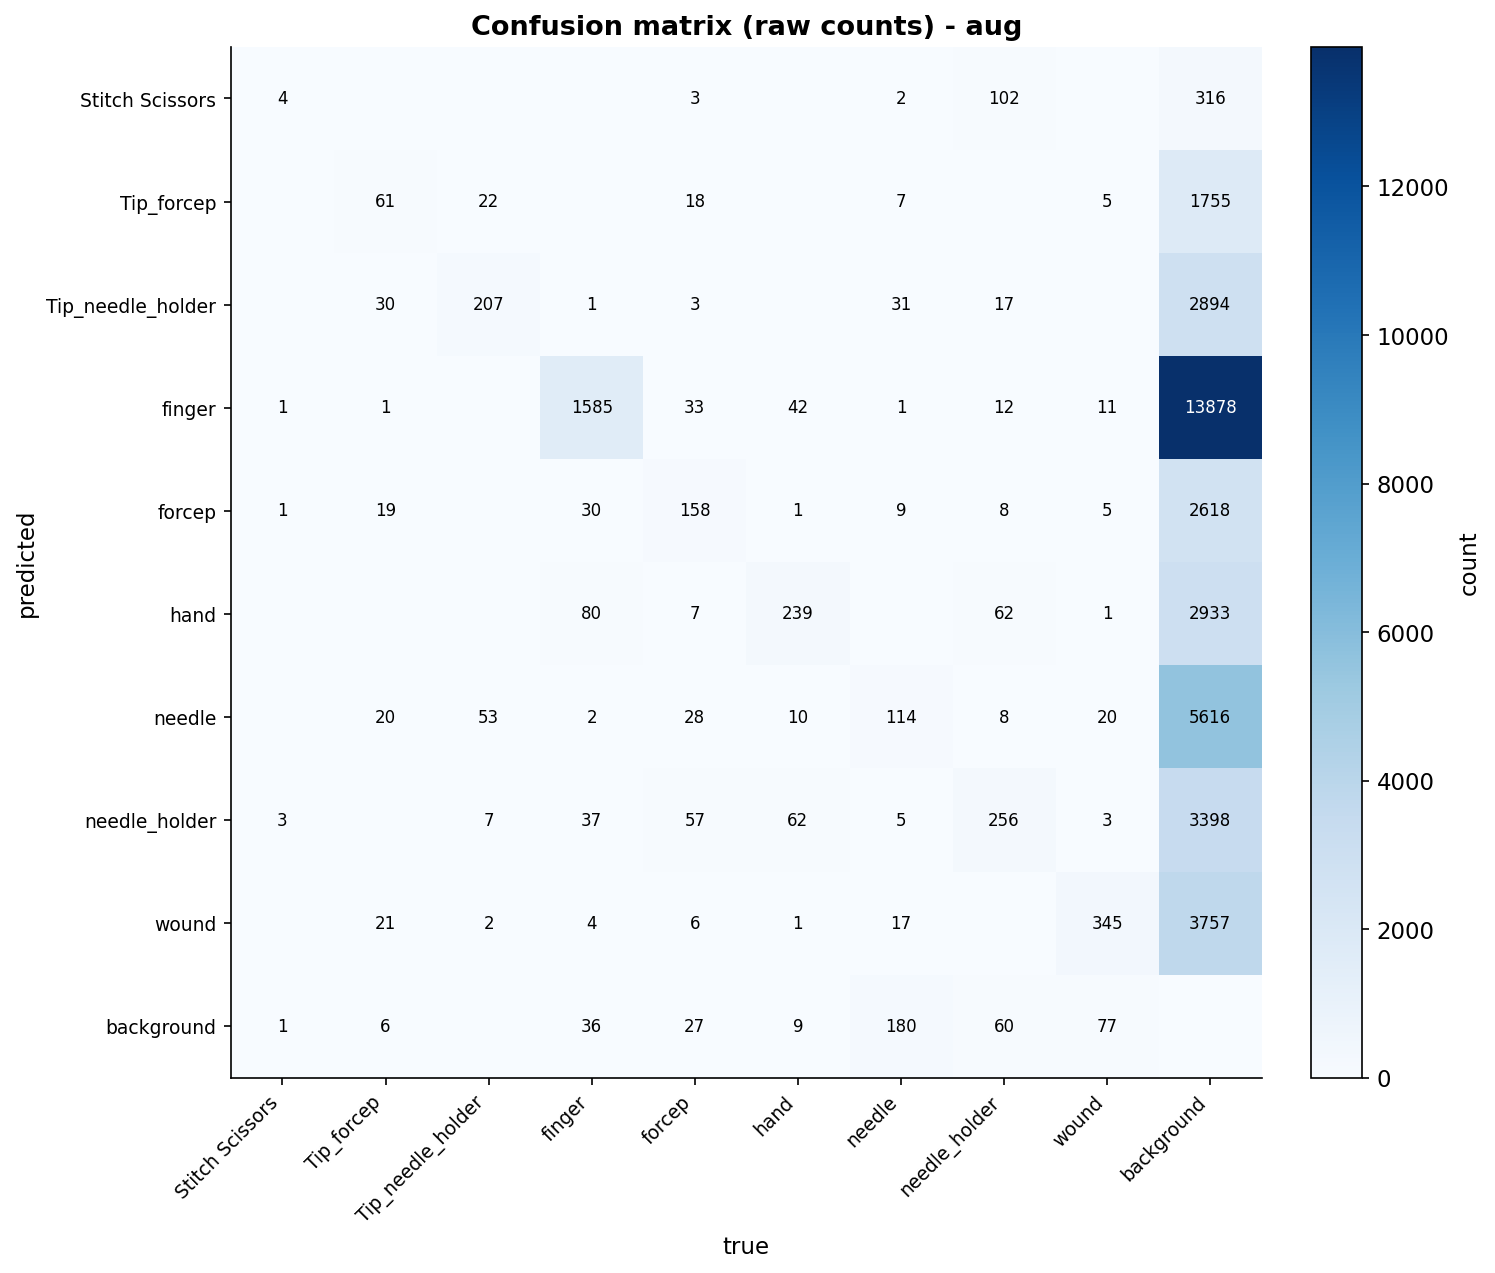

In [11]:
display(Image(filename='results/aug_confusion_matrix_raw.png'))

**Confusion matrix, normalised per true class - test set**


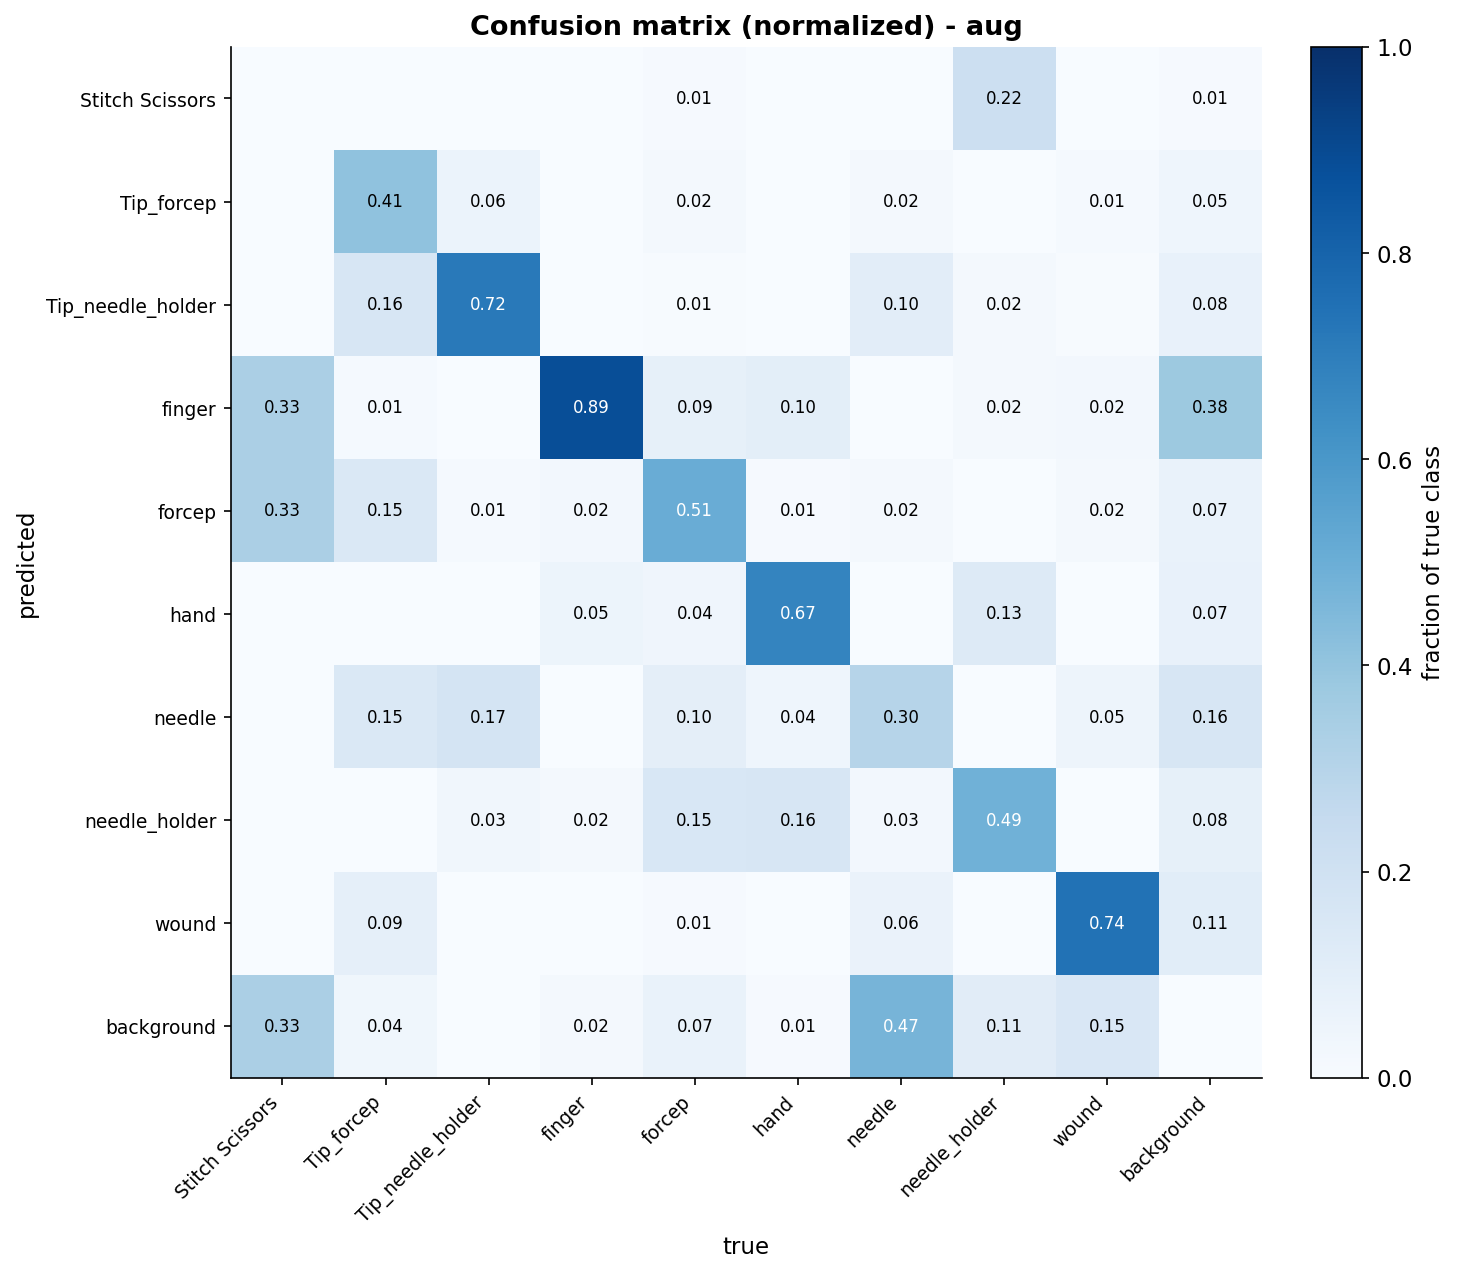

In [12]:
display(Image(filename='results_test/aug_confusion_matrix_normalized.png'))

## 5. Threshold behaviour

How precision, recall and F1 move as the confidence threshold changes - the curves to consult before picking an operating point.


**Precision-recall per class**


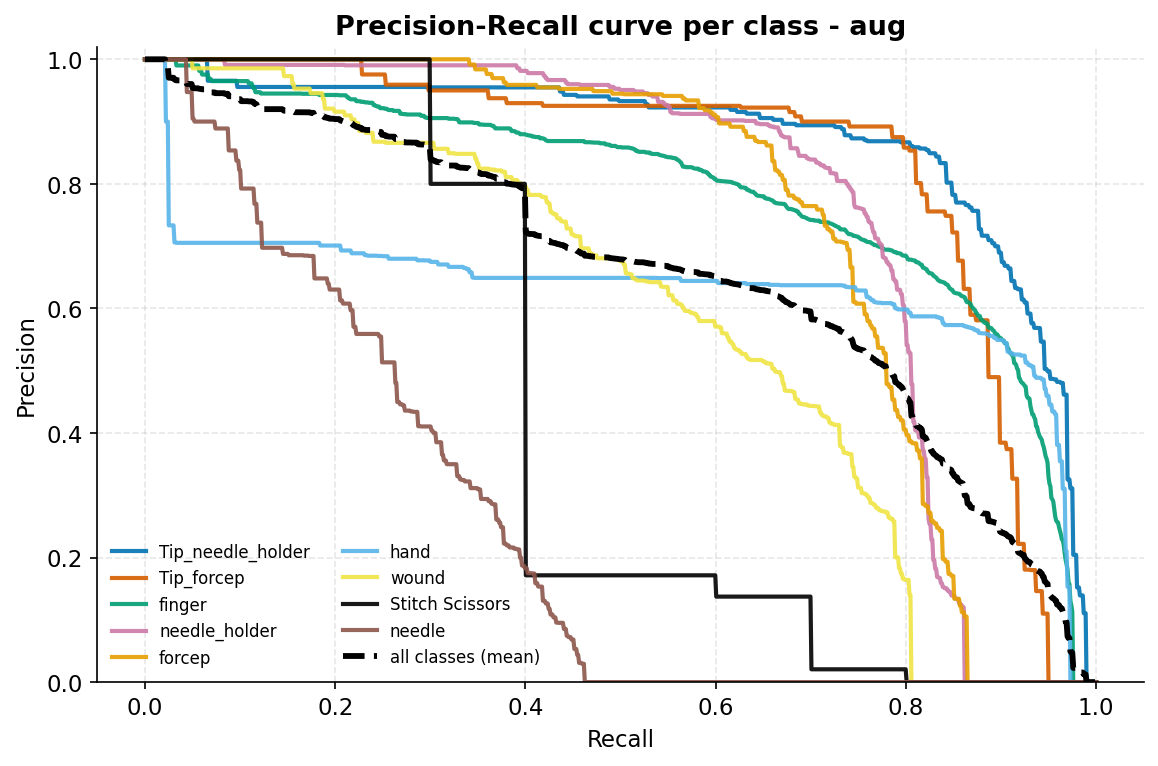

In [13]:
display(Image(filename='results/aug_pr_curve_per_class.png'))

**F1 vs confidence**


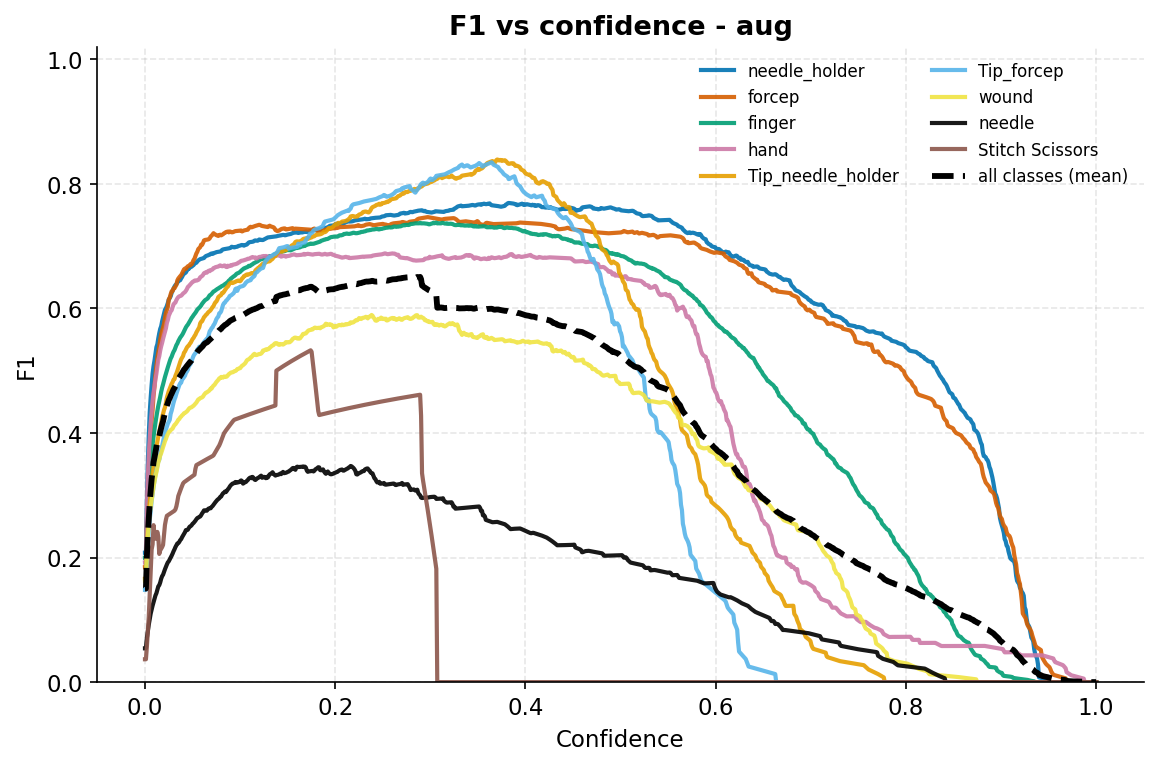

In [14]:
display(Image(filename='results/aug_f1_confidence_curve.png'))

**Precision vs confidence**


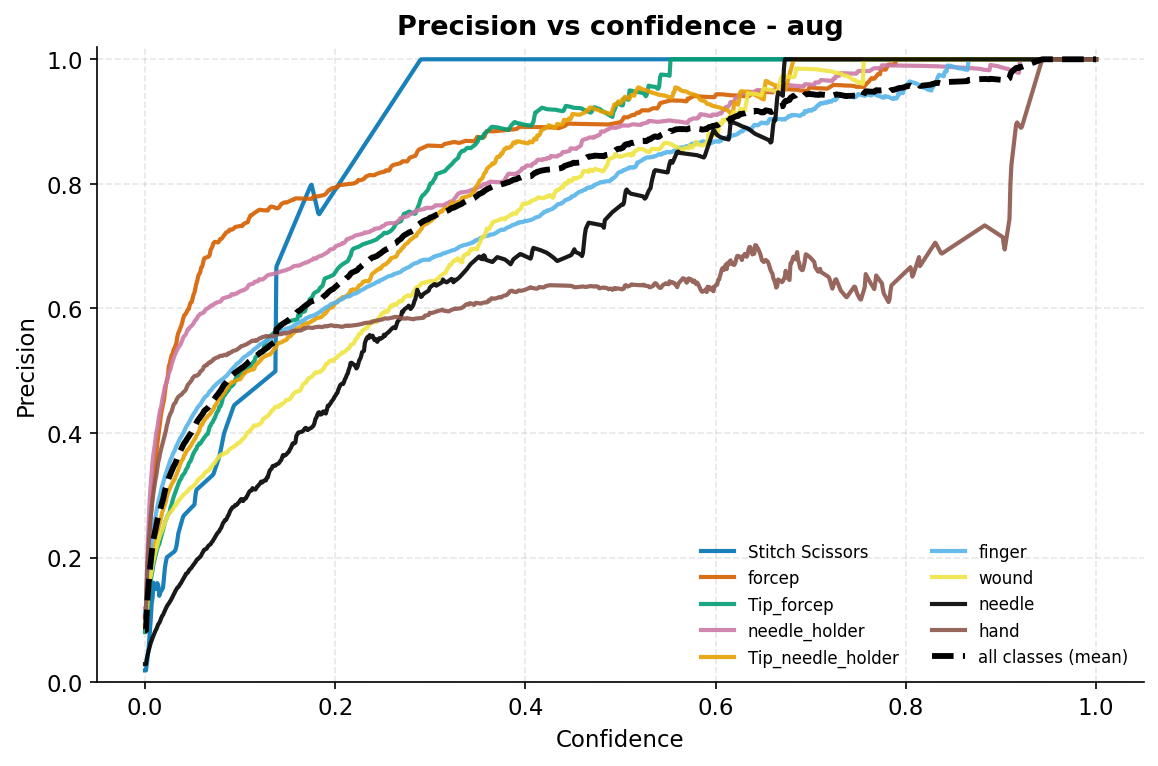

In [15]:
display(Image(filename='results/aug_precision_confidence_curve.png'))

**Recall vs confidence**


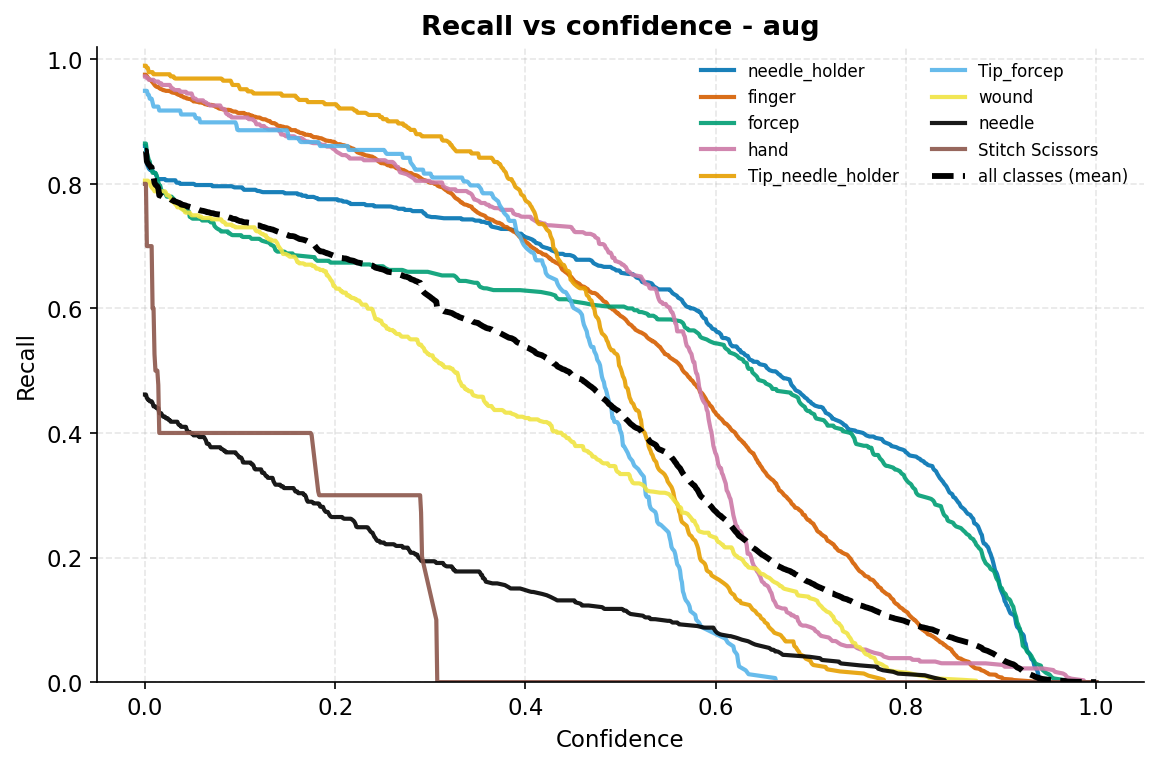

In [16]:
display(Image(filename='results/aug_recall_confidence_curve.png'))

## 6. Error analysis

The easiest and hardest validation frames, ranked by false positives plus false negatives at IoU 0.5. Green solid is ground truth, orange dashed is the prediction.


**Best and worst validation frames**


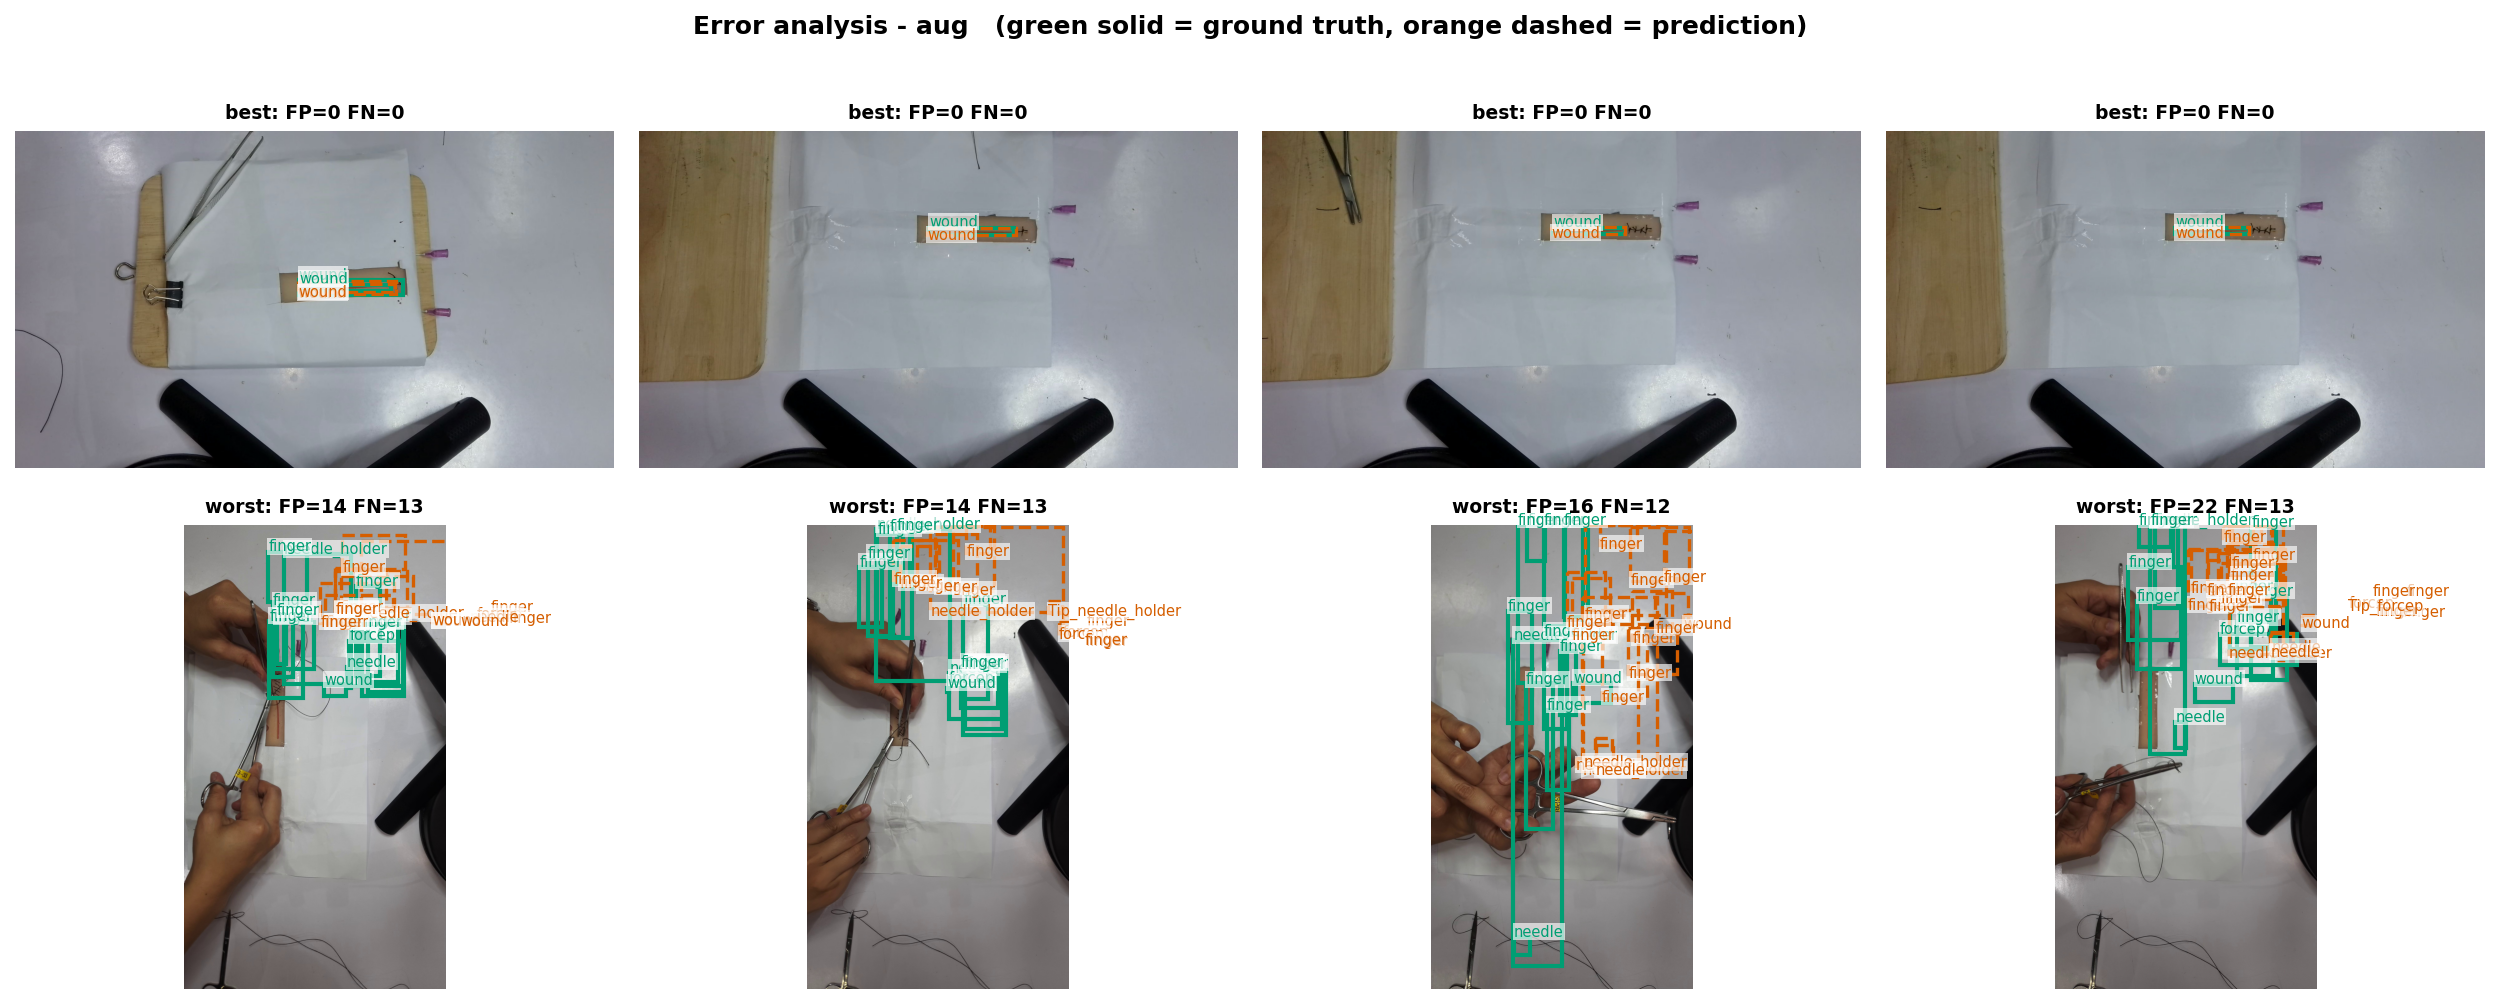

In [17]:
display(Image(filename='results/aug_error_analysis_grid.png'))

## 7. Class distribution

Instances (boxes), not images: one frame routinely holds several objects, so image counts would understate the imbalance.


**Instances per class per split**


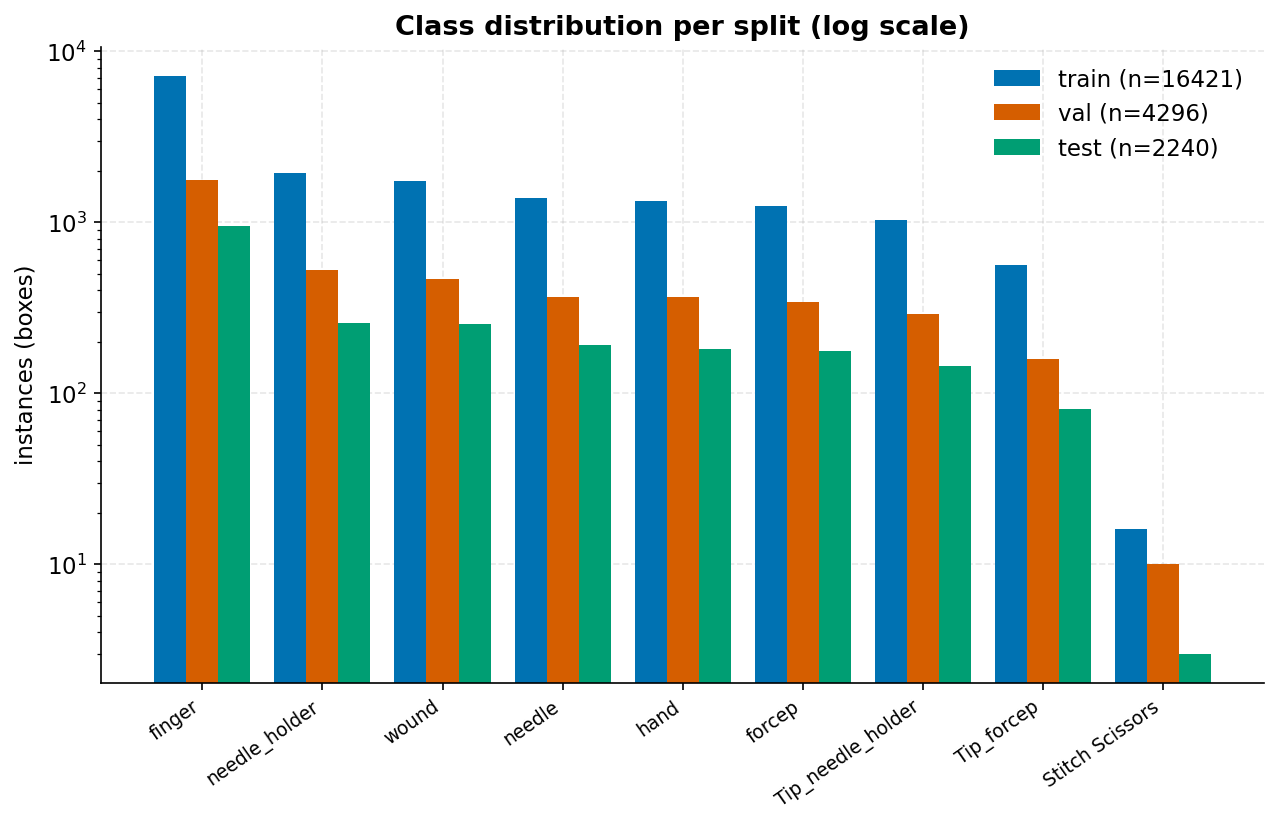

In [18]:
display(Image(filename='results/class_distribution.png'))